# 3. Modeling

The goal of this section is to develop machine learning models capable of predicting manufacturing defects.

The modeling workflow includes:

- Loading processed datasets
- Building a baseline model
- Training Random Forest
- Training XGBoost
- Comparing model performance
- Identifying the best-performing model

## 3.1 Import Libraries

In [13]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

## 3.2 Load Processed Data

Load the datasets created during the feature engineering stage.

In [14]:
X_train = pd.read_csv("/Users/junghanlee/Downloads/1. Python Code/3. Manufacturing Defect Prediction/1. Data/X_train.csv")
X_test = pd.read_csv("/Users/junghanlee/Downloads/1. Python Code/3. Manufacturing Defect Prediction/1. Data/X_test.csv")

y_train = pd.read_csv("/Users/junghanlee/Downloads/1. Python Code/3. Manufacturing Defect Prediction/1. Data/y_train.csv")
y_test = pd.read_csv("/Users/junghanlee/Downloads/1. Python Code/3. Manufacturing Defect Prediction/1. Data/y_test.csv")

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((946997, 100), (236750, 100), (946997, 1), (236750, 1))

## 3.3 Baseline Model

A baseline model provides a reference point for evaluating more advanced machine learning algorithms.

In [16]:
baseline_prediction = np.zeros(
    len(y_test)
)

baseline_prediction[:5]

array([0., 0., 0., 0., 0.])

In [17]:
accuracy_score(
    y_test,
    baseline_prediction
)

0.9941879619852165

### Observation

Because the dataset is highly imbalanced, predicting all products as non-defective may achieve high accuracy.

Therefore, accuracy alone is not sufficient for evaluating model performance.

## 3.4 Random Forest

Random Forest is a tree-based ensemble model that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [24]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [25]:
rf.fit(
    X_train,
    y_train.values.ravel()
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [27]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Accuracy : 0.9915733896515312
Precision: 0.13716295427901523
Recall   : 0.08502906976744186
F1 Score : 0.10497981157469717
ROC-AUC  : 0.6106305182464681


## 3.5 Random Forest Feature Importance

Feature importance provides insight into which manufacturing measurements contribute most to defect prediction.

In [11]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(20)

L3_S33_F3857    0.037076
L3_S30_F3749    0.032640
L3_S30_F3759    0.032223
L3_S30_F3774    0.028795
L3_S30_F3809    0.028657
L3_S29_F3479    0.025228
L3_S30_F3784    0.024424
L3_S30_F3519    0.024139
L3_S30_F3494    0.024030
L3_S30_F3819    0.023934
L3_S30_F3499    0.023764
L3_S29_F3348    0.023501
L3_S29_F3401    0.023226
L3_S29_F3395    0.023209
L3_S29_F3345    0.023136
L3_S30_F3794    0.022002
L3_S30_F3799    0.021689
L0_S11_F314     0.020109
L3_S30_F3764    0.019919
L3_S29_F3458    0.019885
dtype: float64

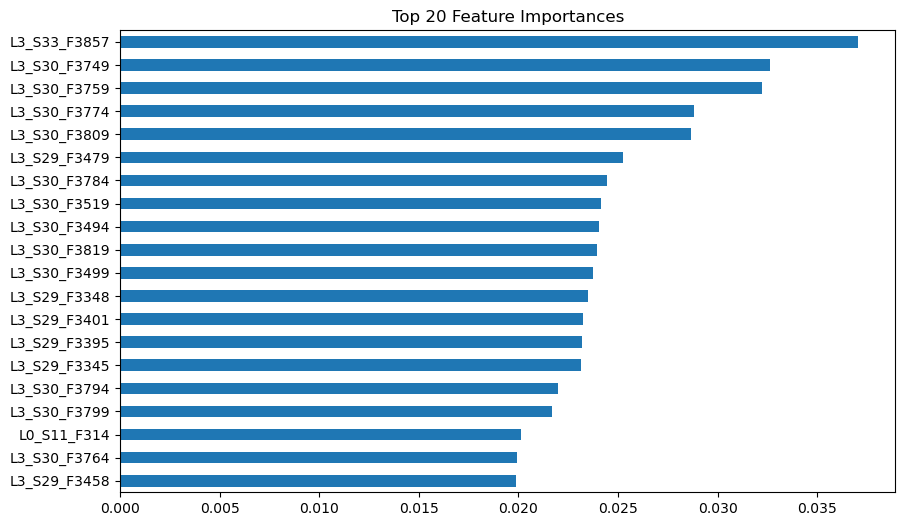

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

feature_importance.head(20).plot(
    kind="barh"
)

plt.title(
    "Top 20 Feature Importances"
)

plt.gca().invert_yaxis()

plt.show()

## 3.6 XGBoost

XGBoost is one of the most widely used gradient boosting algorithms for structured tabular data.

In [19]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb.fit(
    X_train,
    y_train.values.ravel()
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [21]:
xgb_pred = xgb.predict(
    X_test
)

xgb_prob = xgb.predict_proba(
    X_test
)[:,1]

In [22]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_auc)

Accuracy : 0.99410348468849
Precision: 0.3684210526315789
Recall   : 0.020348837209302327
F1 Score : 0.03856749311294766
ROC-AUC  : 0.6984394090720736


## 3.7 Model Comparison

In [23]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "F1 Score": [rf_f1, xgb_f1],
    "ROC-AUC": [rf_auc, xgb_auc]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.992959,0.178808,0.058866,0.088573,0.610793
1,XGBoost,0.994103,0.368421,0.020349,0.038567,0.698439


## 3.8 Modeling Summary

### Completed Steps

- Built a baseline classifier
- Trained Random Forest
- Trained XGBoost
- Compared model performance
- Identified important manufacturing measurements

### Next Steps

In the next notebook:

1. Evaluate model performance in detail
2. Create confusion matrix
3. Plot ROC curve
4. Analyze Precision-Recall tradeoffs
5. Apply SHAP explainability